# Import Libraries

In [ ]:
!pip install gensim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
from sklearn.decomposition import PCA

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.6 MB/s eta 0:00:00


# Load Dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kanchana1990/biomedical-research-abstracts-20242026")

print("Path to dataset files:", path)

100%|██████████| 80.1M/80.1M [00:02<00:00, 32.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kanchana1990/biomedical-research-abstracts-20242026/versions/1


# Read Dataset

In [ ]:
import pandas as pd
import os

# List the contents of the downloaded directory to find the correct CSV file name.
files_in_path = os.listdir(path)
print(f"Files in downloaded path: {files_in_path}")

# Assuming the CSV file is directly in the downloaded path and has a similar name,
# or we need to find it programmatically. For now, let's assume it's the only CSV.
csv_files = [f for f in files_in_path if f.endswith('.csv')]

if csv_files:
    csv_file_name = csv_files[0] # Assuming the first CSV file found is the correct one
    full_csv_path = os.path.join(path, csv_file_name)
    print(f"Identified CSV file: {full_csv_path}")
    df = pd.read_csv(full_csv_path)
    print(df.head())
else:
    print("No CSV files found in the downloaded directory.")
    # If no CSV files are found, you might need to manually inspect the dataset structure
    # or adjust the logic to look into subdirectories if necessary.

Files in downloaded path: ['biomedical_research_abstracts_2024_2026.csv']
Identified CSV file: /root/.cache/kagglehub/datasets/kanchana1990/biomedical-research-abstracts-20242026/versions/1/biomedical_research_abstracts_2024_2026.csv
       pmid                                              title  \
0  41869676  The genome sequence of the bloodfluke planorb,...   
1  41841041  An exploratory study of critical incidents wit...   
2  41797731  From Mary Shelley to Netflix: a Pan-European p...   
3  41726542  Improving electronic health record processing ...   
4  41726541  Developing a User-Centered Mobile Application ...   

                                            abstract  abstract_words  \
0  We present a genome assembly from an individua...              57   
1  Leadership changes within public organizations...             250   
2  Scientific knowledge of the human brain has ca...             244   
3  Large language models (LLMs) excel in natural ...             134   
4  This s

# Text Preprocessing

In [ ]:
nltk.download('punkt') # For word tokenization
nltk.download('stopwords') # For stopwords
nltk.download('punkt_tab') # Required for some NLTK tokenization scenarios

# Lowercase
def preprocess_text(text):
  text = text.lower()
  # Remove special character
  text = re.sub(r'[^a-zA-Z\s]', '', text)
  # Tokenize and remove stopwords
  words = nltk.word_tokenize(text)
  stop_words = set(stopwords.words('english'))
  words = [w for w in words if w not in stop_words]
  return words

# Assuming 'abstract' is the column to be processed
df['tokenized_text'] = df['abstract'].apply(preprocess_text)
tokenized_data = df['tokenized_text'].tolist()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Train CBOW Model

In [ ]:
cbow_model = Word2Vec(sentences = tokenized_data,vector_size=100,# Embedding Size
                      window = 5,   # Context Window
                      min_count = 2, # Ignore rare words
                      sg = 0)  # CBOW

# Train Skip-Gram Model

In [8]:
skipgram_model = Word2Vec(sentences = tokenized_data,vector_size=100,
                          window = 5,
                          min_count = 2,
                          sg = 1)  # Skip Gram

# Compare Similar Words

In [9]:
word = "market"

print("\nCBOW Similar Words:")
print(cbow_model.wv.most_similar(word))

print("\nSkip-Gram Similar Words:")
print(skipgram_model.wv.most_similar(word))


CBOW Similar Words:
[('markets', 0.8392860889434814), ('price', 0.8236355781555176), ('prices', 0.8148999214172363), ('stock', 0.7809991836547852), ('companies', 0.7688432931900024), ('firms', 0.7455804944038391), ('enterprises', 0.7432407140731812), ('imports', 0.7378700375556946), ('trade', 0.7333934307098389), ('sales', 0.7299288511276245)]

Skip-Gram Similar Words:
[('prices', 0.8047762513160706), ('price', 0.8017463088035583), ('markets', 0.7964838147163391), ('suppliers', 0.7719650864601135), ('companies', 0.7563597559928894), ('commerce', 0.7480357885360718), ('wholesale', 0.7409713268280029), ('pricing', 0.73544842004776), ('industry', 0.7317019701004028), ('woms', 0.729266881942749)]


# Cosine Similarity Comparsion

In [10]:
w1, w2 = 'market','economy'

print("\nCBOW Similar Words:")
print(cbow_model.wv.most_similar(w1, w2))

print("\nSkip-Gram Similar Words:")
print(skipgram_model.wv.most_similar(w1, w2))


CBOW Similar Words:
[('prescription', 0.5149387717247009), ('prescriptions', 0.4803559482097626), ('psychotropic', 0.4646146893501282), ('illicit', 0.45911791920661926), ('discounts', 0.4519492983818054), ('markups', 0.44262659549713135), ('antipsychotic', 0.43479955196380615), ('dispenses', 0.414916068315506), ('prescribed', 0.4084569811820984), ('kampo', 0.40323197841644287)]

Skip-Gram Similar Words:
[('sold', 0.3450935184955597), ('prescriptions', 0.33419135212898254), ('purchased', 0.330269455909729), ('biosimilar', 0.32631370425224304), ('formulations', 0.3258035182952881), ('stores', 0.324564129114151), ('marketed', 0.31767886877059937), ('price', 0.31624162197113037), ('granules', 0.31460440158843994), ('asm', 0.31184783577919006)]


# Visualization using PCA

In [11]:
def plot_embedding(model, title):

  # Top 15 Words
  words = list(model.wv.index_to_key)[:20]
  vector = model.wv[words]

  # Reduce dimensions
  pca = PCA(n_components=2)
  result = pca.fit_transform(vector)

  # Create a scatter plot
  plt.figure(figsize=(10, 6))
  plt.scatter(result[:, 0], result[:, 1])

  for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))

  plt.title(title)
  plt.show()

# Plot CBOW

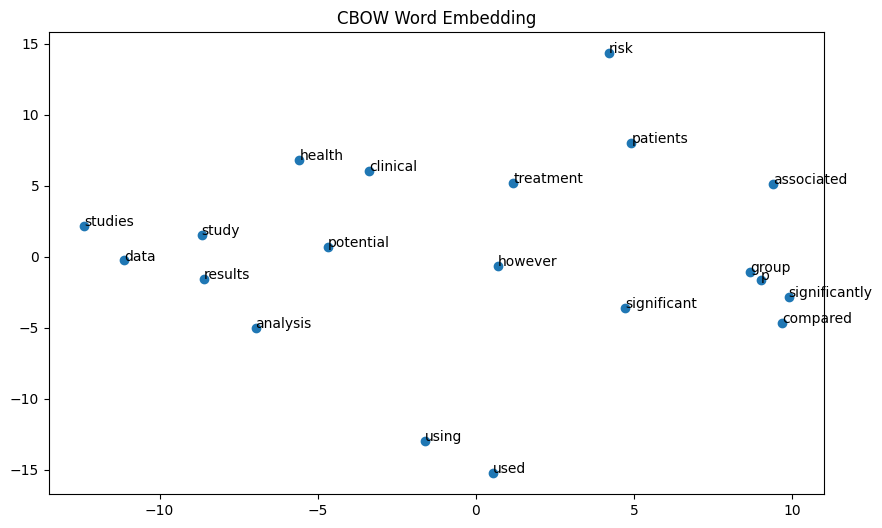

In [12]:
plot_embedding(cbow_model, 'CBOW Word Embedding')

# Plot Skip-Gram

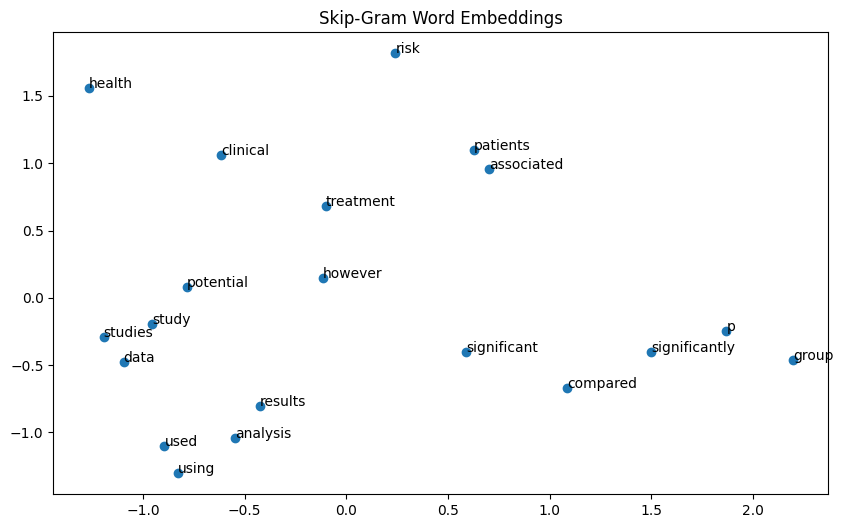

In [13]:
plot_embedding(skipgram_model, 'Skip-Gram Word Embeddings')